In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import joblib
import pickle

import matplotlib.pyplot as plt

In [4]:
data_prefix = "../0_data/processed_data/"
model_types = ['LGB']
label = 'MP_label'
non_feature_cols = ['SMILES', 'MP', 'Type'] + [label]
data_types = ['L', 'H', 'All']

In [5]:
# Model development
# =========================
def model_development(data, non_feature_cols, model_type, trials):
    X = data.drop(columns=non_feature_cols)
    y = data['MP'].values
    strat_labels = data[label].values

    # Precompute and store the exact same CV folds
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    folds = list(skf.split(X, strat_labels))

    # ---- Helper: run 10-fold CV for a given model instance ----
    def run_cv(model_instance):
        fold_rmses = []
        for train_idx, val_idx in folds:
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model_instance.fit(X_train, y_train)
            preds = model_instance.predict(X_val)
            fold_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
        return fold_rmses

    # ---- Model + search space definitions ----
    if model_type == 'RF':
        default_model = RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )
        base_model = RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )
        search_space = {
            'n_estimators': Integer(20, 500),
            'max_depth': Integer(3, 12),
            'min_samples_split': Integer(2, 10),
            'min_samples_leaf': Integer(1, 10),
            'max_features': Real(0.1, 1.0),
        }

    elif model_type == 'LGB':
        default_model = lgb.LGBMRegressor(
            random_state=42,
            bagging_seed=42,
            feature_fraction_seed=42,
            data_random_seed=42,
            deterministic=True,
            force_col_wise=True,
            n_jobs=1,
            verbose=-1
        )
        base_model = lgb.LGBMRegressor(
            random_state=42,
            bagging_seed=42,
            feature_fraction_seed=42,
            data_random_seed=42,
            deterministic=True,
            force_col_wise=True,
            n_jobs=1,
            verbose=-1
        )
        search_space = {
            'num_leaves': Integer(20, 300),
            'max_depth': Integer(3, 12),
            'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
            'n_estimators': Integer(200, 2000),  # raised for better boosting-curve behavior
            'min_child_samples': Integer(10, 50),
            'subsample': Real(0.6, 1.0),
            'colsample_bytree': Real(0.4, 1.0),
            'reg_alpha': Real(1e-5, 10.0, prior='log-uniform'),
            'reg_lambda': Real(1e-5, 10.0, prior='log-uniform'),
        }

    elif model_type == 'XGB':
        default_model = xgb.XGBRegressor(
            random_state=42,
            n_jobs=-1,
            tree_method='hist',
            verbosity=0
        )
        base_model = xgb.XGBRegressor(
            random_state=42,
            n_jobs=-1,
            tree_method='hist',
            verbosity=0
        )
        search_space = {
            'n_estimators': Integer(20, 500),
            'max_depth': Integer(3, 12),
            'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0),
            'colsample_bytree': Real(0.4, 1.0),
            'reg_alpha': Real(1e-5, 10.0, prior='log-uniform'),
            'reg_lambda': Real(1e-5, 10.0, prior='log-uniform'),
            'min_child_weight': Integer(1, 10),
        }

    else:
        raise ValueError(f"model_type must be 'RF', 'LGB', or 'XGB'; got '{model_type}'")

    # ---- Trial 0: default hyperparameters ----
    trial_results = {}
    fold_rmses_0 = run_cv(default_model)
    mean_0 = float(np.mean(fold_rmses_0))
    std_0 = float(np.std(fold_rmses_0))
    trial_results[0] = {
        'fold_rmses': fold_rmses_0,
        'mean_rmse': mean_0,
        'std_rmse': std_0
    }
    print(f"Trial  0 (default) | mean RMSE: {mean_0:.4f} ± {std_0:.4f}")

    # ---- Trials 1-n: BayesSearchCV ----
    opt = BayesSearchCV(
        estimator=base_model,
        search_spaces=search_space,
        n_iter=trials,
        cv=folds,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=1,
        refit=True,
    )
    opt.fit(X, y)

    # Extract per-trial fold RMSEs from cv_results_
    n_splits = len(folds)
    for i in range(trials):
        fold_rmses = [-opt.cv_results_[f'split{s}_test_score'][i] for s in range(n_splits)]
        mean_rmse = float(np.mean(fold_rmses))
        std_rmse = float(np.std(fold_rmses))
        trial_results[i + 1] = {
            'fold_rmses': fold_rmses,
            'mean_rmse': mean_rmse,
            'std_rmse': std_rmse,
        }
        print(f"Trial {i+1:>2d} | mean RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")

    return trial_results, opt.best_estimator_, folds

In [6]:
# Plot HP tuning performance

def plot_model_performance(model_development_results_dict, title=None):
    trials = sorted(model_development_results_dict.keys())
    mean_rmses = np.array([model_development_results_dict[t]['mean_rmse'] for t in trials])
    std_rmses = np.array([model_development_results_dict[t]['std_rmse'] for t in trials])

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(trials, mean_rmses, marker='o', linewidth=1.5, color='steelblue', label='Mean RMSE')
    ax.fill_between(
        trials,
        mean_rmses - std_rmses,
        mean_rmses + std_rmses,
        alpha=0.25,
        color='steelblue',
        label='± 1 std'
    )

    ax.axvline(x=0, color='grey', linestyle='--', linewidth=1, label='Default HP (trial 0)')

    best_trial = trials[int(np.argmin(mean_rmses))]
    best_rmse = float(np.min(mean_rmses))
    ax.scatter([best_trial], [best_rmse], color='red', zorder=5,
               label=f'Best (trial {best_trial}, RMSE={best_rmse:.4f})')

    ax.set_xlabel('HP Tuning Iteration', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title(title if title else 'Model Performance vs. HP Tuning Iteration', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

In [7]:
# Learning-curve extraction for LightGBM

def get_lgb_learning_curve_cv(data, non_feature_cols, best_model, folds,
                              early_stopping_rounds=50):
    """
    Reuse the same CV folds and record train/validation RMSE vs boosting iteration.
    """
    X = data.drop(columns=non_feature_cols)
    y = data['MP'].values

    train_curves = []
    val_curves = []
    best_iterations = []
    fold_final_metrics = []

    for fold_num, (train_idx, val_idx) in enumerate(folds, start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Get tuned parameters and refit model for this fold
        params = best_model.get_params().copy()

        # For learning curve purposes, allow many iterations and let early stopping decide
        params['n_estimators'] = max(params.get('n_estimators', 500), 2000)

        # Keep training deterministic
        params['random_state'] = 42
        params['bagging_seed'] = 42
        params['feature_fraction_seed'] = 42
        params['data_random_seed'] = 42
        params['deterministic'] = True
        params['force_col_wise'] = True
        params['n_jobs'] = 1
        params['verbose'] = -1

        model = lgb.LGBMRegressor(**params)

        evals_result = {}

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            eval_names=['train', 'valid'],
            eval_metric='rmse',
            callbacks=[
                lgb.record_evaluation(evals_result),
                lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False)
            ]
        )

        train_rmse = evals_result['train']['rmse']
        valid_rmse = evals_result['valid']['rmse']

        train_curves.append(train_rmse)
        val_curves.append(valid_rmse)
        best_iterations.append(model.best_iteration_)

        fold_final_metrics.append({
            'fold': fold_num,
            'best_iteration': model.best_iteration_,
            'final_train_rmse': train_rmse[-1],
            'final_valid_rmse': valid_rmse[-1]
        })

        print(
            f"Fold {fold_num:>2d} | "
            f"best_iteration = {model.best_iteration_:>4d} | "
            f"final train RMSE = {train_rmse[-1]:.4f} | "
            f"final valid RMSE = {valid_rmse[-1]:.4f}"
        )

    # Pad variable-length curves with NaN for averaging
    max_len = max(max(len(c) for c in train_curves), max(len(c) for c in val_curves))

    train_mat = np.full((len(train_curves), max_len), np.nan)
    val_mat = np.full((len(val_curves), max_len), np.nan)

    for i, curve in enumerate(train_curves):
        train_mat[i, :len(curve)] = curve
    for i, curve in enumerate(val_curves):
        val_mat[i, :len(curve)] = curve

    learning_curve_results = {
        'train_curves': train_curves,
        'val_curves': val_curves,
        'train_mat': train_mat,
        'val_mat': val_mat,
        'mean_train_rmse': np.nanmean(train_mat, axis=0),
        'std_train_rmse': np.nanstd(train_mat, axis=0),
        'mean_val_rmse': np.nanmean(val_mat, axis=0),
        'std_val_rmse': np.nanstd(val_mat, axis=0),
        'best_iterations': best_iterations,
        'mean_best_iteration': float(np.mean(best_iterations)),
        'median_best_iteration': int(np.median(best_iterations)),
        'fold_final_metrics': fold_final_metrics
    }

    return learning_curve_results

In [8]:
# Plot learning curve

def plot_lgb_learning_curve(learning_curve_results, title=None):
    mean_train = learning_curve_results['mean_train_rmse']
    std_train = learning_curve_results['std_train_rmse']
    mean_val = learning_curve_results['mean_val_rmse']
    std_val = learning_curve_results['std_val_rmse']
    median_best_iteration = learning_curve_results['median_best_iteration']

    iterations = np.arange(1, len(mean_train) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(iterations, mean_train, linewidth=2, label='Train RMSE', color='royalblue')
    ax.fill_between(
        iterations,
        mean_train - std_train,
        mean_train + std_train,
        alpha=0.20,
        color='royalblue'
    )

    ax.plot(iterations, mean_val, linewidth=2, label='Validation RMSE', color='darkorange')
    ax.fill_between(
        iterations,
        mean_val - std_val,
        mean_val + std_val,
        alpha=0.20,
        color='darkorange'
    )

    ax.axvline(
        x=median_best_iteration,
        color='grey',
        linestyle='--',
        linewidth=1.5,
        label=f'Median best iteration = {median_best_iteration}'
    )

    ax.set_xlabel('Boosting Iteration', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title(title if title else 'LightGBM Learning Curve', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()



=== Model: LGB ===
=== Data Type: L ===
Dataset shape: (11439, 93) (n_samples=11439, n_features=89)
Trial  0 (default) | mean RMSE: 34.1538 ± 1.1195
Trial  1 | mean RMSE: 33.1447 ± 1.1394
Trial  2 | mean RMSE: 34.0768 ± 1.3043
Trial  3 | mean RMSE: 34.1332 ± 1.3839
Trial  4 | mean RMSE: 32.9872 ± 1.2226
Trial  5 | mean RMSE: 32.6453 ± 1.2250
Trial  6 | mean RMSE: 34.5303 ± 1.1150
Trial  7 | mean RMSE: 33.4835 ± 1.2641
Trial  8 | mean RMSE: 34.1518 ± 1.2696
Trial  9 | mean RMSE: 33.1584 ± 1.2429
Trial 10 | mean RMSE: 33.6524 ± 1.4069
Trial 11 | mean RMSE: 33.0507 ± 1.1427
Trial 12 | mean RMSE: 32.6014 ± 1.1832
Trial 13 | mean RMSE: 32.7365 ± 1.3614
Trial 14 | mean RMSE: 33.4789 ± 1.3087
Trial 15 | mean RMSE: 34.6935 ± 1.2034
Trial 16 | mean RMSE: 32.7744 ± 1.1260
Trial 17 | mean RMSE: 32.7743 ± 1.3612
Trial 18 | mean RMSE: 32.6879 ± 1.2167
Trial 19 | mean RMSE: 32.3676 ± 1.2132
Trial 20 | mean RMSE: 32.4598 ± 1.2413


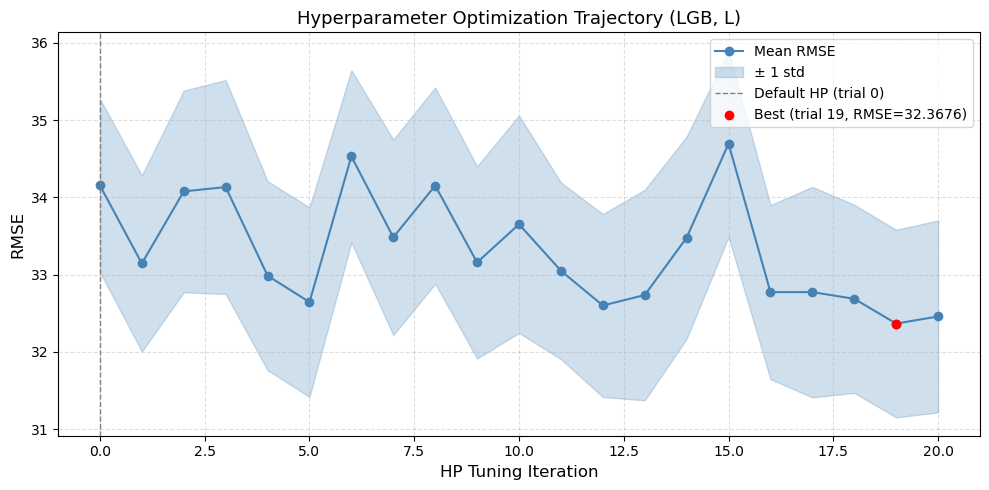


=== Learning curve analysis for LGB (L) ===
Fold  1 | best_iteration = 1990 | final train RMSE = 9.2265 | final valid RMSE = 32.9141
Fold  2 | best_iteration = 1240 | final train RMSE = 12.6037 | final valid RMSE = 31.3793
Fold  3 | best_iteration = 1422 | final train RMSE = 11.4591 | final valid RMSE = 31.9349
Fold  4 | best_iteration = 1514 | final train RMSE = 10.8879 | final valid RMSE = 34.1635
Fold  5 | best_iteration = 1867 | final train RMSE = 9.3803 | final valid RMSE = 32.3974
Fold  6 | best_iteration = 1759 | final train RMSE = 9.9631 | final valid RMSE = 34.5610
Fold  7 | best_iteration = 1995 | final train RMSE = 9.1380 | final valid RMSE = 32.6251
Fold  8 | best_iteration = 1832 | final train RMSE = 9.9043 | final valid RMSE = 32.3805
Fold  9 | best_iteration = 2000 | final train RMSE = 9.1954 | final valid RMSE = 30.7477
Fold 10 | best_iteration = 2000 | final train RMSE = 9.4060 | final valid RMSE = 30.7559


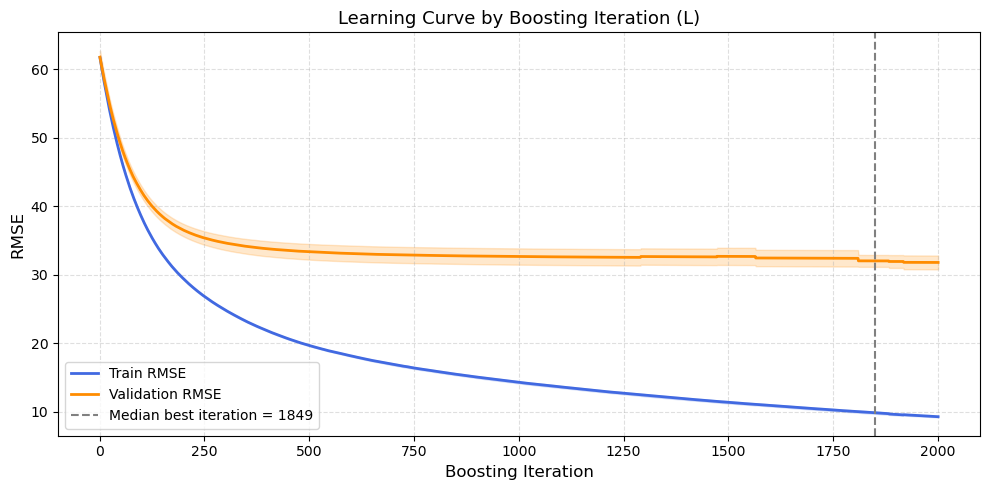


=== Model: LGB ===
=== Data Type: H ===
Dataset shape: (615, 59) (n_samples=615, n_features=55)
Trial  0 (default) | mean RMSE: 28.5375 ± 4.9134
Trial  1 | mean RMSE: 28.1245 ± 4.5135
Trial  2 | mean RMSE: 29.7815 ± 3.6162
Trial  3 | mean RMSE: 29.0694 ± 4.2319
Trial  4 | mean RMSE: 28.9139 ± 4.1158
Trial  5 | mean RMSE: 29.2098 ± 3.9228
Trial  6 | mean RMSE: 29.4226 ± 5.0270
Trial  7 | mean RMSE: 29.9938 ± 3.9484
Trial  8 | mean RMSE: 29.9002 ± 3.4492
Trial  9 | mean RMSE: 28.6928 ± 4.3596
Trial 10 | mean RMSE: 29.1524 ± 4.4890
Trial 11 | mean RMSE: 28.1023 ± 4.3113
Trial 12 | mean RMSE: 28.8763 ± 5.2641
Trial 13 | mean RMSE: 28.5852 ± 4.5307
Trial 14 | mean RMSE: 29.0258 ± 4.2797
Trial 15 | mean RMSE: 28.6056 ± 4.8217
Trial 16 | mean RMSE: 28.6825 ± 4.6205
Trial 17 | mean RMSE: 28.3977 ± 5.3554
Trial 18 | mean RMSE: 28.2039 ± 5.1945
Trial 19 | mean RMSE: 28.4454 ± 5.5557
Trial 20 | mean RMSE: 28.3082 ± 4.3925


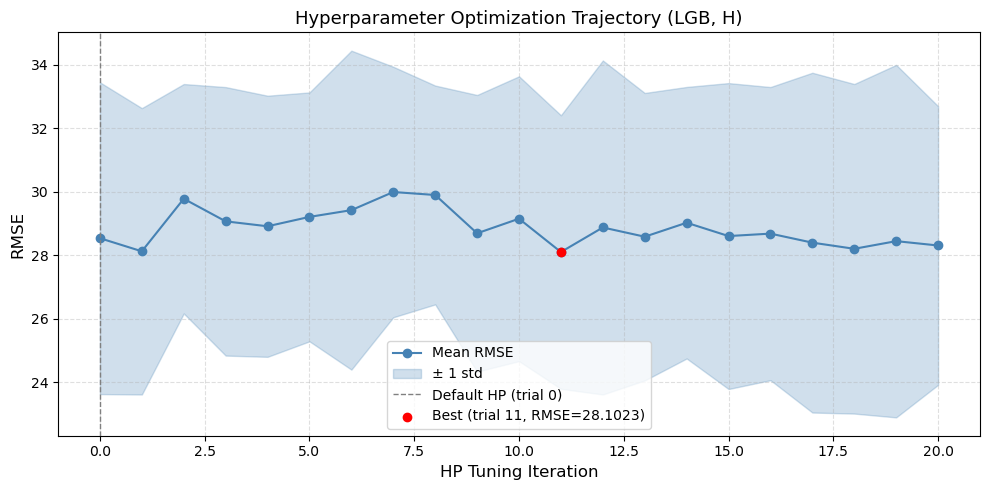


=== Learning curve analysis for LGB (H) ===
Fold  1 | best_iteration =   25 | final train RMSE = 14.0684 | final valid RMSE = 29.8772
Fold  2 | best_iteration =  139 | final train RMSE = 6.5606 | final valid RMSE = 30.6634
Fold  3 | best_iteration =   59 | final train RMSE = 10.6792 | final valid RMSE = 34.6950
Fold  4 | best_iteration =  579 | final train RMSE = 0.9514 | final valid RMSE = 34.7345
Fold  5 | best_iteration =   28 | final train RMSE = 14.1101 | final valid RMSE = 25.2716
Fold  6 | best_iteration =  544 | final train RMSE = 1.2113 | final valid RMSE = 29.7060
Fold  7 | best_iteration =   19 | final train RMSE = 15.2015 | final valid RMSE = 23.7352
Fold  8 | best_iteration =   72 | final train RMSE = 9.9496 | final valid RMSE = 21.5322
Fold  9 | best_iteration =   36 | final train RMSE = 13.2972 | final valid RMSE = 23.9146
Fold 10 | best_iteration =  192 | final train RMSE = 4.5039 | final valid RMSE = 24.6509


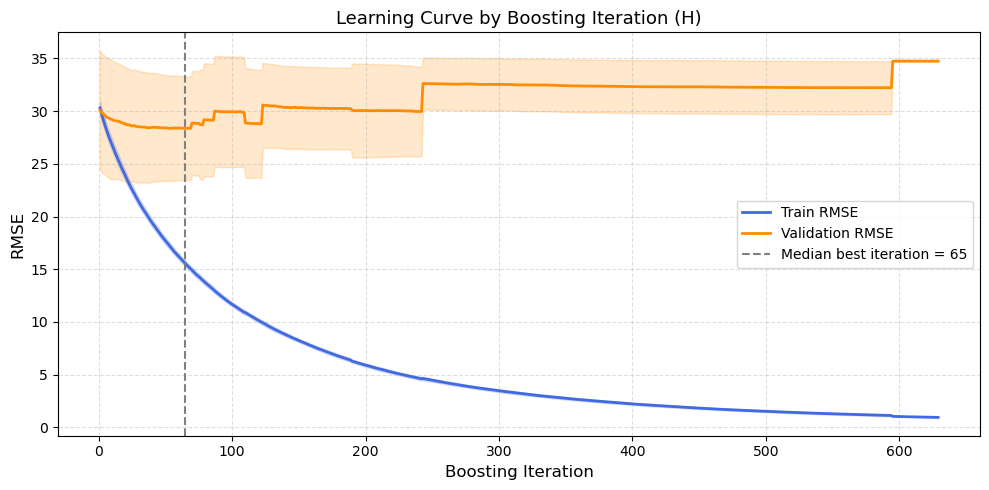


=== Model: LGB ===
=== Data Type: All ===
Dataset shape: (12054, 87) (n_samples=12054, n_features=83)
Trial  0 (default) | mean RMSE: 37.4802 ± 1.2050
Trial  1 | mean RMSE: 36.5190 ± 1.2213
Trial  2 | mean RMSE: 37.1076 ± 1.3348
Trial  3 | mean RMSE: 37.0428 ± 1.6106
Trial  4 | mean RMSE: 36.2412 ± 1.2976
Trial  5 | mean RMSE: 35.8905 ± 1.1283
Trial  6 | mean RMSE: 37.3475 ± 1.2858
Trial  7 | mean RMSE: 36.4042 ± 1.1440
Trial  8 | mean RMSE: 37.1625 ± 1.4209
Trial  9 | mean RMSE: 36.3142 ± 1.0754
Trial 10 | mean RMSE: 36.7932 ± 1.3300
Trial 11 | mean RMSE: 40.8428 ± 1.2104
Trial 12 | mean RMSE: 35.8635 ± 1.2089
Trial 13 | mean RMSE: 42.7321 ± 1.0067
Trial 14 | mean RMSE: 39.3532 ± 1.3185
Trial 15 | mean RMSE: 37.5886 ± 1.5393
Trial 16 | mean RMSE: 37.5024 ± 1.4331
Trial 17 | mean RMSE: 36.8389 ± 1.3082
Trial 18 | mean RMSE: 36.0246 ± 1.3471
Trial 19 | mean RMSE: 36.8670 ± 1.3739
Trial 20 | mean RMSE: 35.8533 ± 1.1695


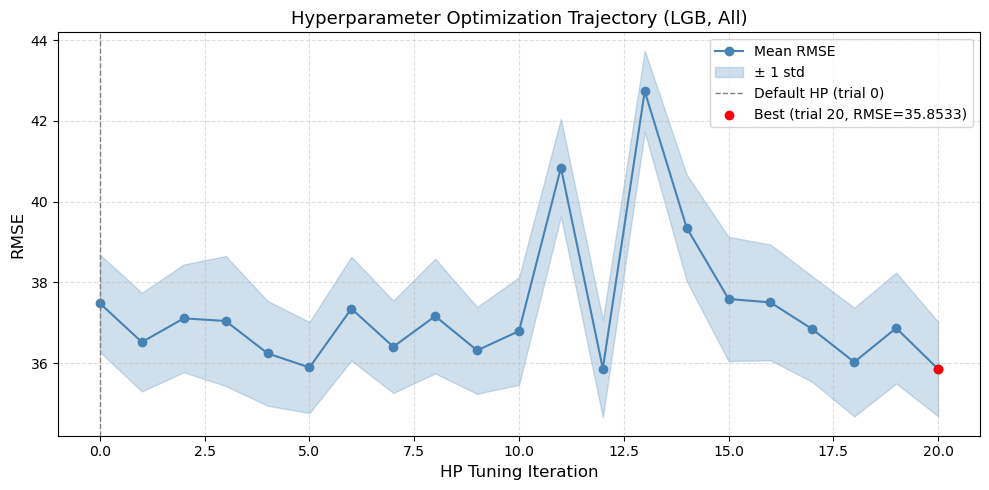


=== Learning curve analysis for LGB (All) ===
Fold  1 | best_iteration =  363 | final train RMSE = 16.2868 | final valid RMSE = 36.2572
Fold  2 | best_iteration =  461 | final train RMSE = 14.8337 | final valid RMSE = 34.9158
Fold  3 | best_iteration =  748 | final train RMSE = 10.6786 | final valid RMSE = 35.7581
Fold  4 | best_iteration =  979 | final train RMSE = 8.6303 | final valid RMSE = 37.4509
Fold  5 | best_iteration =  710 | final train RMSE = 11.0230 | final valid RMSE = 35.6761
Fold  6 | best_iteration =  415 | final train RMSE = 15.2936 | final valid RMSE = 38.2194
Fold  7 | best_iteration =  625 | final train RMSE = 11.9207 | final valid RMSE = 36.1967
Fold  8 | best_iteration =  773 | final train RMSE = 10.4666 | final valid RMSE = 35.5777
Fold  9 | best_iteration =  511 | final train RMSE = 13.5371 | final valid RMSE = 34.3886
Fold 10 | best_iteration =  728 | final train RMSE = 11.2523 | final valid RMSE = 34.3980


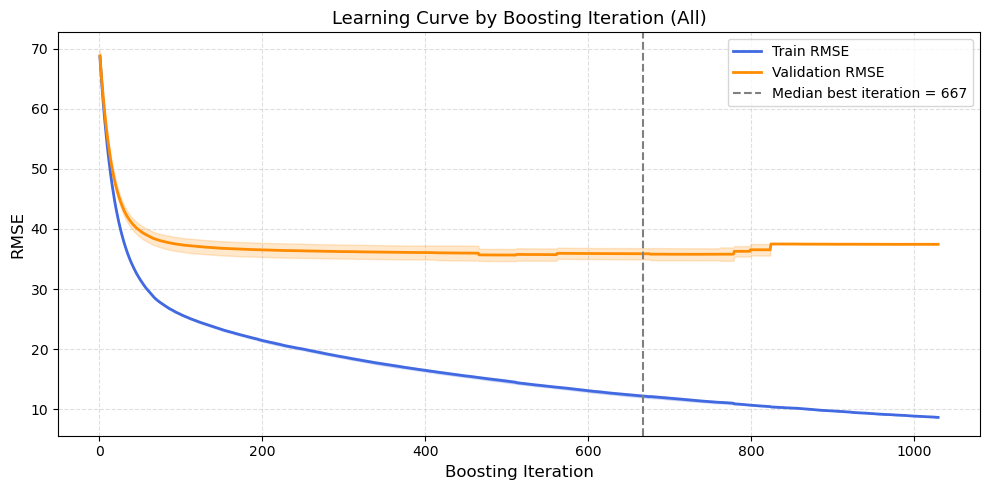

In [9]:
# Main run

for model in model_types:
    for data_type in data_types:

        data = pd.read_parquet(
            data_prefix + f"data_with_selected_features_{model}_{data_type}_scaled.parquet"
        )
        data = data[data['Type'] == 'Train'].reset_index(drop=True)

        if data_type != 'All':
            data = data[data[label] == data_type].reset_index(drop=True)

        print(f"\n=== Model: {model} ===")
        print(f"=== Data Type: {data_type} ===")
        print(f"Dataset shape: {data.shape} "
              f"(n_samples={data.shape[0]}, "
              f"n_features={data.shape[1] - len(non_feature_cols)})")

        # ---- model development ----
        trial_results, best_model, folds = model_development(
            data=data,
            non_feature_cols=non_feature_cols,
            model_type=model,
            trials=20
        )

        with open(f'LC_model_development_results_{model}_{data_type}.pkl', 'wb') as f:
            pickle.dump(trial_results, f)

        joblib.dump(best_model, f"LC_best_model_{model}_{data_type}.joblib", compress=3)

        # ---- HP tuning plot ----
        plot_model_performance(
            trial_results,
            title=f'Hyperparameter Optimization Trajectory ({model}, {data_type})'
        )

        # ---- learning curve for LightGBM only ----
        if model == 'LGB':
            print(f"\n=== Learning curve analysis for {model} ({data_type}) ===")

            learning_curve_results = get_lgb_learning_curve_cv(
                data=data,
                non_feature_cols=non_feature_cols,
                best_model=best_model,
                folds=folds,
                early_stopping_rounds=50
            )

            with open(f'lgb_learning_curve_results_{data_type}.pkl', 'wb') as f:
                pickle.dump(learning_curve_results, f)

            plot_lgb_learning_curve(
                learning_curve_results,
                title=f'Learning Curve by Boosting Iteration ({data_type})'
            )

In [ ]:
#############------------------------- UNDERSAMPLING FOR SHAP ANALYSIS------------------################

In [ ]:
# For undersampling

for model in model_types:
    for data_type in data_types:

        data = pd.read_parquet(
            data_prefix + f"data_with_selected_features_{model}_{data_type}_scaled.parquet"
        )
        data = data[data['Type'] == 'Train'].reset_index(drop=True)

        if data_type != 'All':
            data = data[data[label] == data_type].reset_index(drop=True)

        print(f"\n=== Model: {model} ===")
        print(f"=== Data Type: {data_type} ===")
        print(f"Dataset shape: {data.shape} "
              f"(n_samples={data.shape[0]}, "
              f"n_features={data.shape[1] - len(non_feature_cols)})")

        # ---- model development ----
        trial_results, best_model, folds = model_development(
            data=data,
            non_feature_cols=non_feature_cols,
            model_type=model,
            trials=20
        )

        with open(f'LC_model_development_results_{model}_{data_type}.pkl', 'wb') as f:
            pickle.dump(trial_results, f)

        joblib.dump(best_model, f"LC_best_model_{model}_{data_type}.joblib", compress=3)

        # ---- HP tuning plot ----
        plot_model_performance(
            trial_results,
            title=f'Hyperparameter Optimization Trajectory ({model}, {data_type})'
        )

        # ---- learning curve for LightGBM only ----
        if model == 'LGB':
            print(f"\n=== Learning curve analysis for {model} ({data_type}) ===")

            learning_curve_results = get_lgb_learning_curve_cv(
                data=data,
                non_feature_cols=non_feature_cols,
                best_model=best_model,
                folds=folds,
                early_stopping_rounds=50
            )

            with open(f'lgb_learning_curve_results_{data_type}.pkl', 'wb') as f:
                pickle.dump(learning_curve_results, f)

            plot_lgb_learning_curve(
                learning_curve_results,
                title=f'Learning Curve by Boosting Iteration ({data_type})'
            )